# 13c) Senator Beck SWin versus TSI/ERA5-Land GOES RGB binary

This applies the same fixed transfer evaluation used in notebooks 13 and 13b:

- spatial-mean Senator Beck RGB values from the existing domain-mean archive;
- notebook-5b TSI-trained 10°C decision-tree thresholds;
- nearest-pixel hourly ERA5-Land 2-m temperature interpolated to each sample;
- hourly upper-station SWin from `PyUp_Unfilt_W` in `SBSP_1hr_2010-2024.csv`;
- SWin cloud for $k_t<0.55$, clear for $k_t>0.85$, with the middle excluded;
- the common 17–23 UTC comparison window.

`PyUp` denotes the pyranometer at the **upper station**, not upwelling radiation.
Preprocessing is performed by `build_senator_beck_binary_timeseries.py`.

## 1. Load and match the binary series

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, balanced_accuracy_score,
    cohen_kappa_score, f1_score,
)

ROOT = Path.cwd()
ANALYSIS = ROOT if (ROOT / 'output_13c_senator_beck_domain_cloud_binary').exists() else ROOT / 'analysis'
OUT = ANALYSIS / 'output_13c_senator_beck_domain_cloud_binary'

rgb = pd.read_csv(OUT / 'senator_beck_rgb_binary_all_available.csv', parse_dates=['time'])
sw = pd.read_csv(OUT / 'senator_beck_sw_binary_all_available.csv', parse_dates=['time'])
compare = rgb[[
    'time', 'red', 'green', 'blue', 'era5_temp_c', 'temp_bin', 'rgb_cloud_binary'
]].merge(
    sw[['time', 'sw_obs', 'sw_clear', 'cos_sza', 'k_t', 'sw_cloud_binary']],
    on='time', how='inner', validate='one_to_one',
)
compare = compare.loc[compare.time.dt.hour.between(17, 23)].reset_index(drop=True)
compare['agree'] = compare.rgb_cloud_binary.eq(compare.sw_cloud_binary)
print(f'Matched 17–23Z observations: {len(compare):,}')
print(f'Dates represented: {compare.time.dt.normalize().nunique():,}')
print(f'Time span: {compare.time.min()} through {compare.time.max()}')
print(f'Agreement: {compare.agree.mean():.3%}')
display(compare.head())

Matched 17–23Z observations: 3,765
Dates represented: 842
Time span: 2022-01-01 20:00:00 through 2024-07-28 18:00:00
Agreement: 86.932%


,time,red,green,blue,era5_temp_c,temp_bin,rgb_cloud_binary,sw_obs,sw_clear,cos_sza,k_t,sw_cloud_binary,agree
0,2022-01-01 20:00:00,0.476651,0.411615,0.158313,-15.252722,"[-20, -10)",0,582.1,595.502480,0.471211,0.977494,0,True
1,2022-01-01 21:00:00,0.513855,0.341866,0.172172,-15.776282,"[-20, -10)",1,505.4,517.533131,0.409515,0.976556,0,False
2,2022-01-01 22:00:00,0.488831,0.241428,0.100529,-16.491003,"[-20, -10)",1,391.7,383.627626,0.303558,1.021042,0,False
3,2022-01-02 18:00:00,0.278496,0.497993,0.102221,-7.822852,"[-10, 0)",0,488.4,567.532485,0.449079,0.860567,0,True
4,2022-01-02 19:00:00,0.257532,0.487065,0.097134,-6.088019,"[-10, 0)",0,570.5,613.685435,0.485599,0.929629,0,True


## 2. Overall confusion matrix and skill

,n,n_dates,accuracy,balanced_accuracy,cohen_kappa,macro_f1,weighted_f1,clear_precision,clear_recall,cloud_precision,cloud_recall
0,3765,842,0.869323,0.874841,0.728146,0.863665,0.870813,0.933025,0.853401,0.783125,0.89628


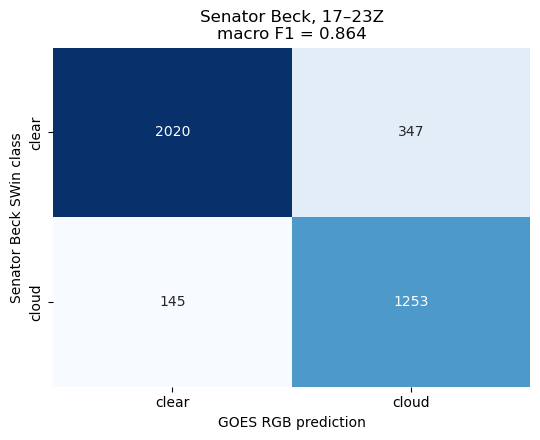

In [2]:
truth, prediction = compare.sw_cloud_binary, compare.rgb_cloud_binary
cm = confusion_matrix(truth, prediction, labels=[0, 1])
report = classification_report(
    truth, prediction, labels=[0, 1], target_names=['clear', 'cloud'],
    output_dict=True, zero_division=0,
)
metrics = pd.DataFrame([{
    'n': len(compare), 'n_dates': compare.time.dt.normalize().nunique(),
    'accuracy': (truth == prediction).mean(),
    'balanced_accuracy': balanced_accuracy_score(truth, prediction),
    'cohen_kappa': cohen_kappa_score(truth, prediction),
    'macro_f1': f1_score(truth, prediction, average='macro', zero_division=0),
    'weighted_f1': f1_score(truth, prediction, average='weighted', zero_division=0),
    'clear_precision': report['clear']['precision'],
    'clear_recall': report['clear']['recall'],
    'cloud_precision': report['cloud']['precision'],
    'cloud_recall': report['cloud']['recall'],
}])
display(metrics)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
ax.set(xlabel='GOES RGB prediction', ylabel='Senator Beck SWin class',
       title=f"Senator Beck, 17–23Z\nmacro F1 = {metrics.macro_f1.iloc[0]:.3f}")
fig.tight_layout()
fig.savefig(OUT / 'senator_beck_binary_confusion_all_available.png', dpi=220)
plt.show()

## 3. Skill by UTC hour

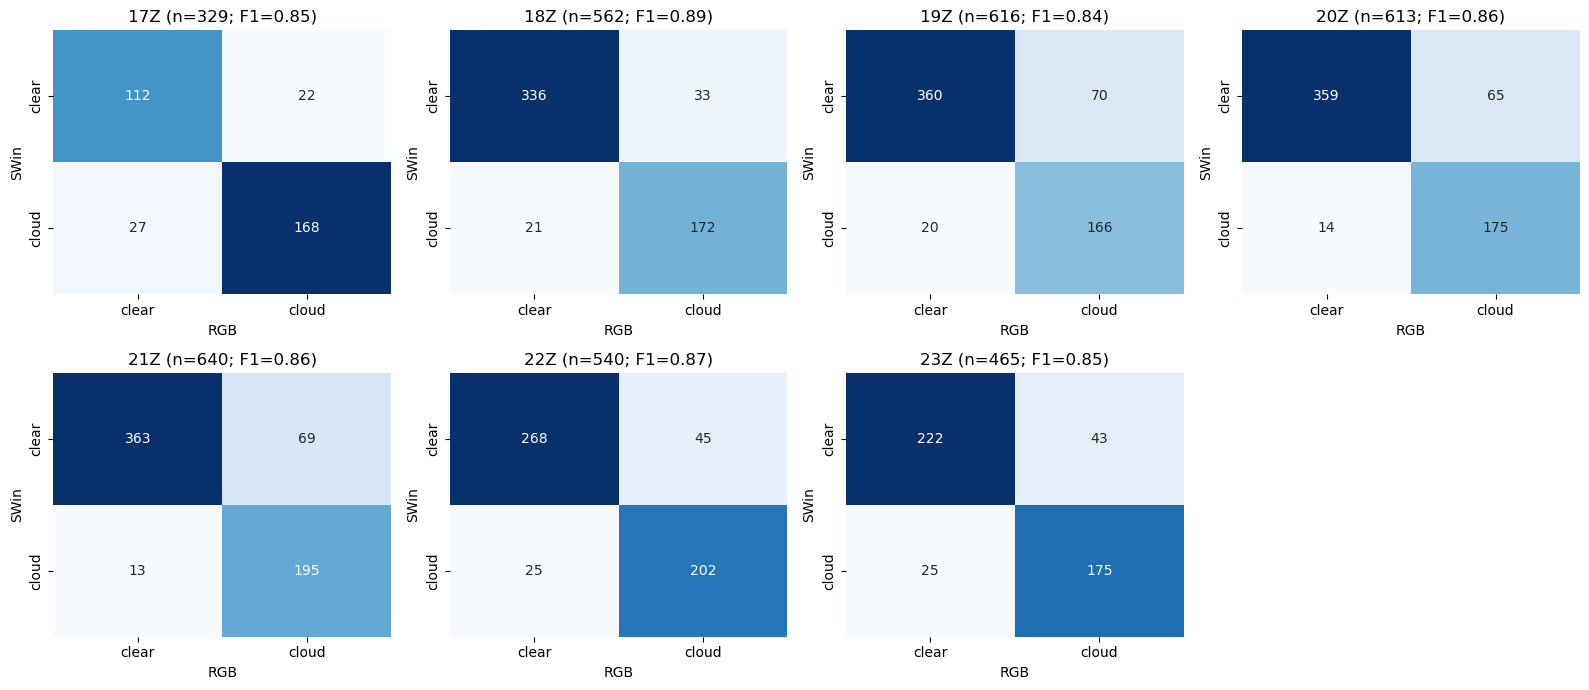

,utc_hour,n,macro_f1,accuracy
0,17,329,0.846620,0.851064
1,18,562,0.894971,0.903915
2,19,616,0.837809,0.853896
3,20,613,0.858365,0.871126
4,21,640,0.862393,0.871875
5,22,540,0.868405,0.870370
6,23,465,0.852254,0.853763


In [3]:
hourly_rows = []
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for hour, ax in zip(range(17, 24), axes.ravel()):
    group = compare.loc[compare.time.dt.hour == hour]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1])
    score = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary,
                     average='macro', zero_division=0)
    hourly_rows.append({'utc_hour': hour, 'n': len(group), 'macro_f1': score,
                        'accuracy': (group.sw_cloud_binary == group.rgb_cloud_binary).mean()})
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
    ax.set_title(f'{hour:02d}Z (n={len(group):,}; F1={score:.2f})')
    ax.set_xlabel('RGB'); ax.set_ylabel('SWin')
axes.ravel()[-1].axis('off')
fig.tight_layout()
fig.savefig(OUT / 'senator_beck_binary_confusion_by_utc_hour.png', dpi=200)
plt.show()
hourly_metrics = pd.DataFrame(hourly_rows)
display(hourly_metrics)

## 4. Skill by month

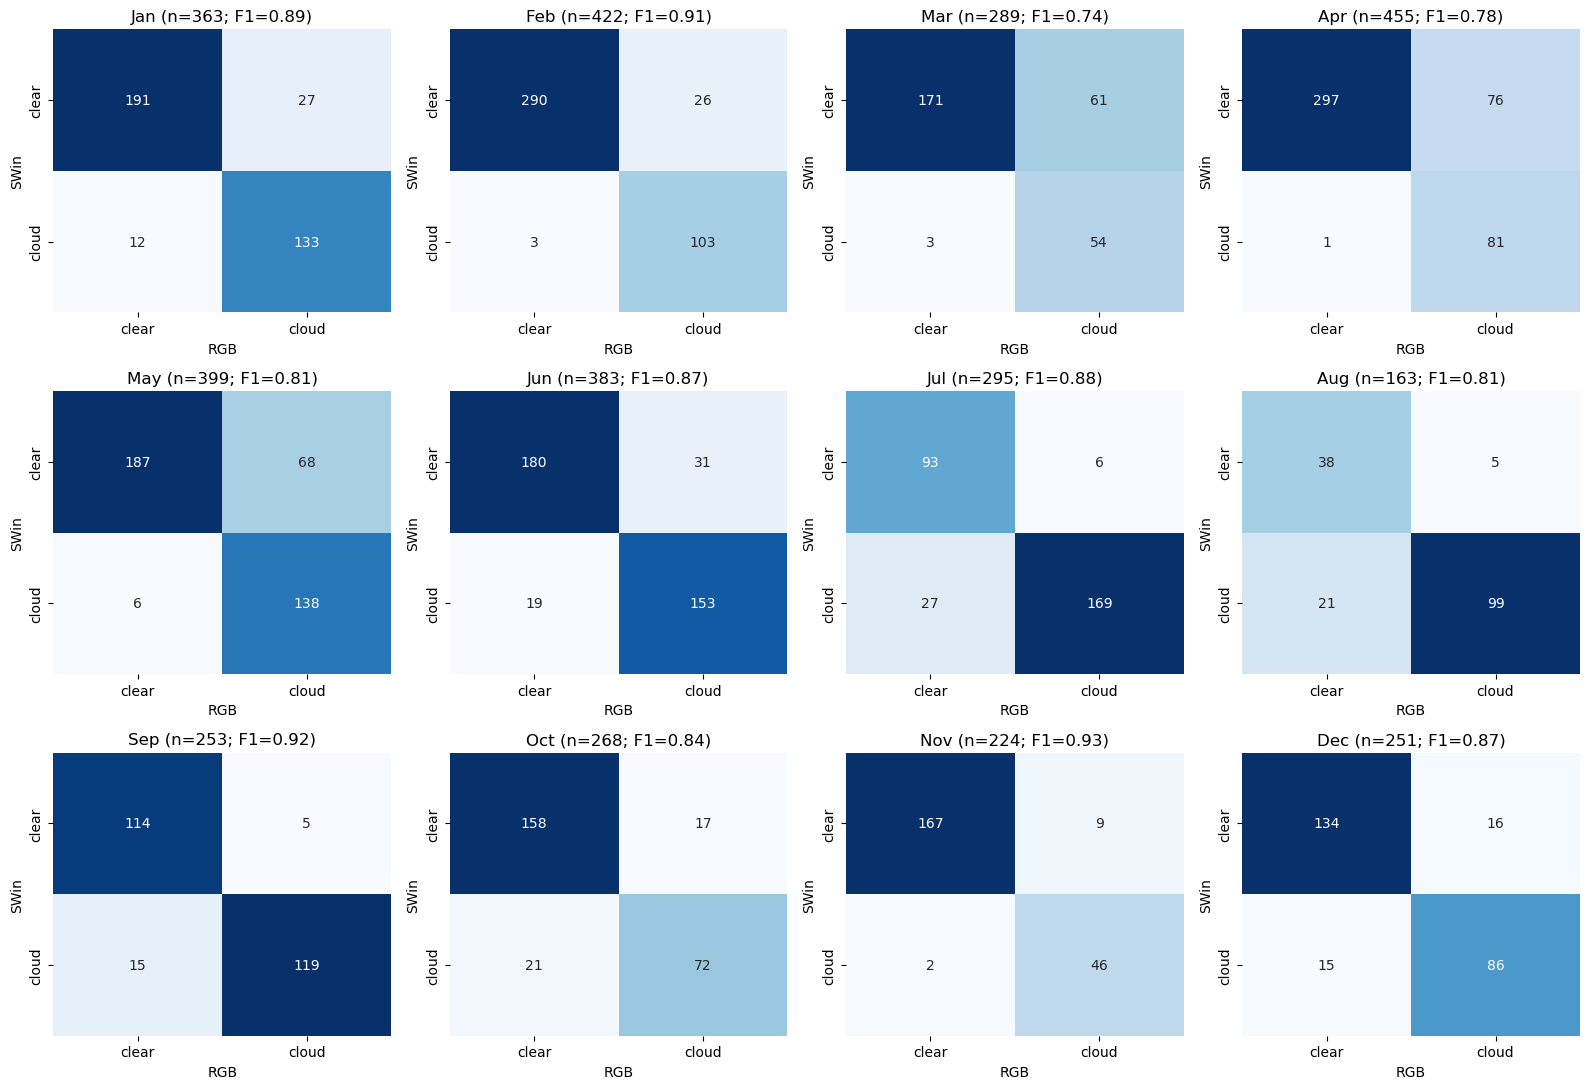

,month,month_name,n,macro_f1,accuracy
0,1,Jan,363,0.889747,0.892562
1,2,Feb,422,0.914488,0.931280
2,3,Mar,289,0.735136,0.778547
3,4,Apr,455,0.781535,0.830769
4,5,May,399,0.811696,0.814536
5,6,Jun,383,0.868800,0.869452
6,7,Jul,295,0.880183,0.888136
7,8,Aug,163,0.814513,0.840491
8,9,Sep,253,0.920918,0.920949
9,10,Oct,268,0.841932,0.858209


In [4]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_rows = []
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for month, ax in enumerate(axes.ravel(), start=1):
    group = compare.loc[compare.time.dt.month == month]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1])
    score = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary,
                     average='macro', zero_division=0) if len(group) else np.nan
    monthly_rows.append({'month': month, 'month_name': month_names[month-1],
                         'n': len(group), 'macro_f1': score,
                         'accuracy': (group.sw_cloud_binary == group.rgb_cloud_binary).mean()
                                     if len(group) else np.nan})
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
    ax.set_title(f'{month_names[month-1]} (n={len(group):,}; F1={score:.2f})')
    ax.set_xlabel('RGB'); ax.set_ylabel('SWin')
fig.tight_layout()
fig.savefig(OUT / 'senator_beck_binary_confusion_by_month.png', dpi=200)
plt.show()
monthly_metrics = pd.DataFrame(monthly_rows)
display(monthly_metrics)

## 5. RGB histograms by ERA5-Land temperature bin

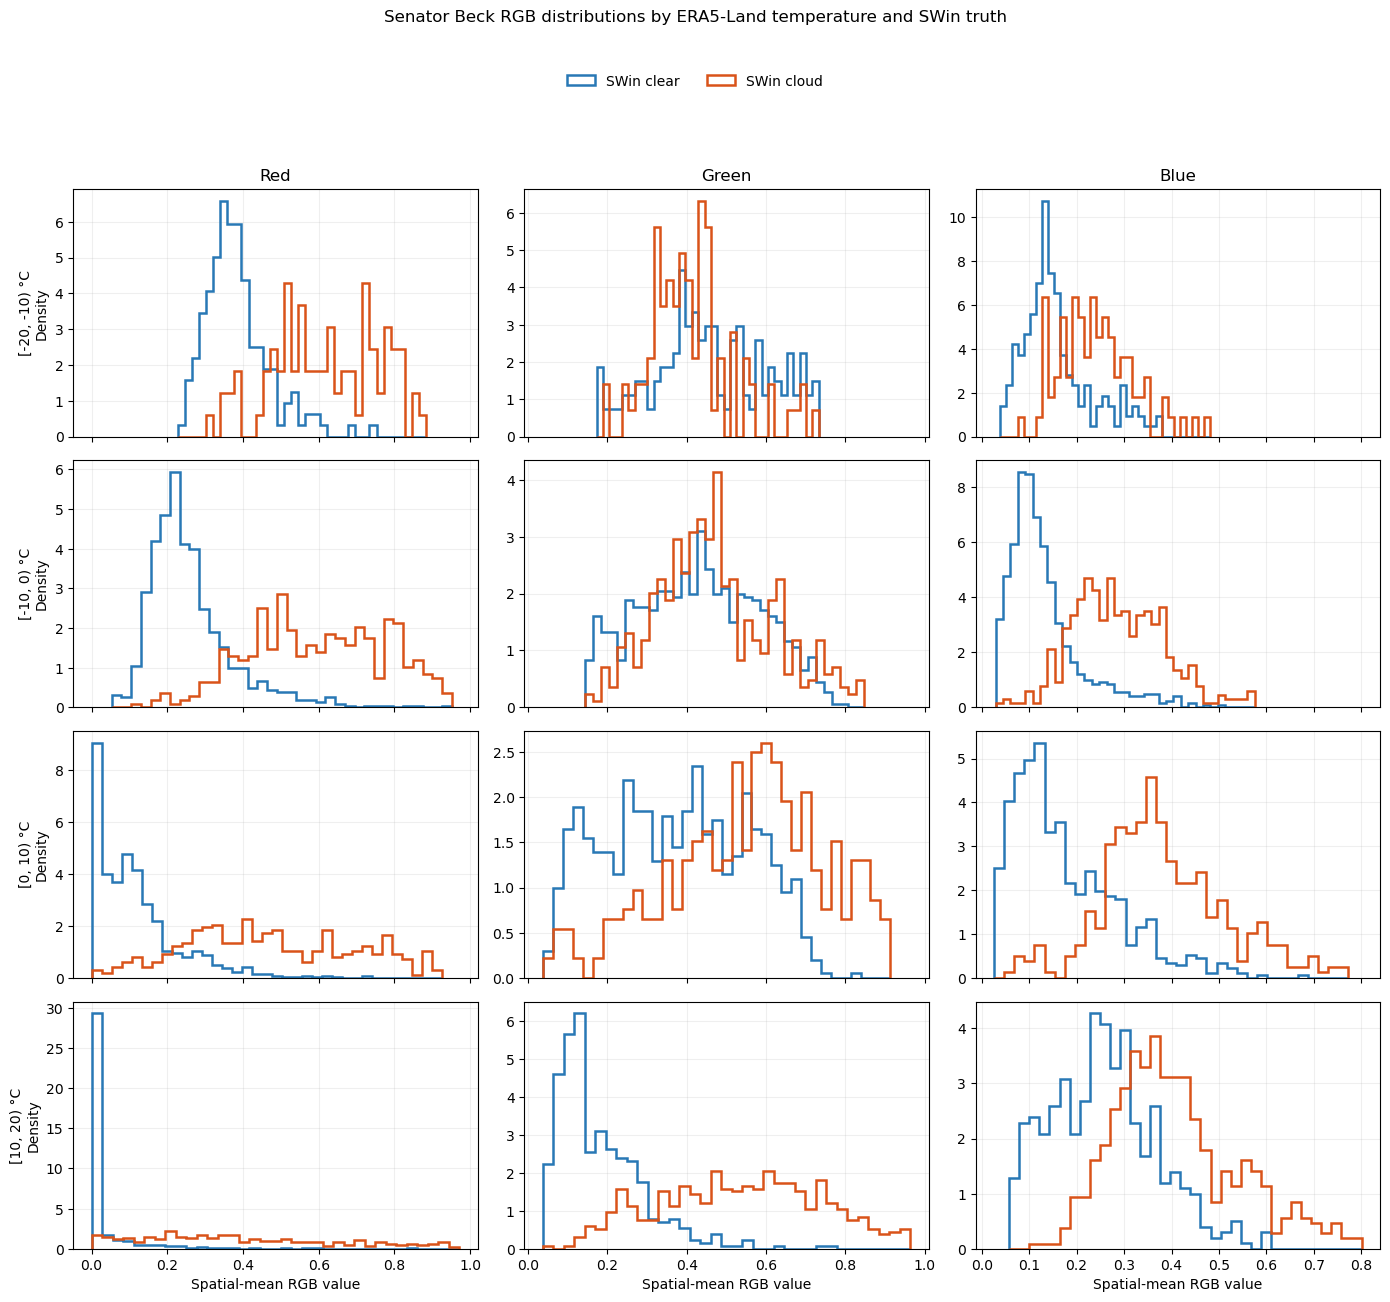

In [5]:
bin_order = ['[-20, -10)', '[-10, 0)', '[0, 10)', '[10, 20)']
bands = ['red', 'green', 'blue']
fig, axes = plt.subplots(4, 3, figsize=(14, 13), sharex='col')
for row, label in enumerate(bin_order):
    panel = compare.loc[compare.temp_bin == label]
    for col, band in enumerate(bands):
        ax = axes[row, col]
        values = panel[band].dropna()
        if values.empty:
            ax.set_visible(False)
            continue
        lo, hi = np.nanpercentile(values, [0.5, 99.5])
        edges = np.linspace(lo, hi, 36)
        for cloud_class, color, name in [(0, '#2878B5', 'SWin clear'),
                                          (1, '#D95319', 'SWin cloud')]:
            subset = panel.loc[panel.sw_cloud_binary == cloud_class, band].dropna()
            if len(subset):
                ax.hist(subset, bins=edges, density=True, histtype='step',
                        linewidth=1.8, color=color, label=name)
        if row == 0: ax.set_title(band.capitalize())
        if col == 0: ax.set_ylabel(f'{label} °C\nDensity')
        if row == 3: ax.set_xlabel('Spatial-mean RGB value')
        ax.grid(alpha=.2)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(.5, .958),
           ncol=2, frameon=False)
fig.suptitle('Senator Beck RGB distributions by ERA5-Land temperature and SWin truth', y=.998)
fig.tight_layout(rect=(0, 0, 1, .91))
fig.savefig(OUT / 'senator_beck_rgb_histograms_by_temperature_bin.png', dpi=220)
plt.show()

## 6. Diagnostic time series for the most complete week

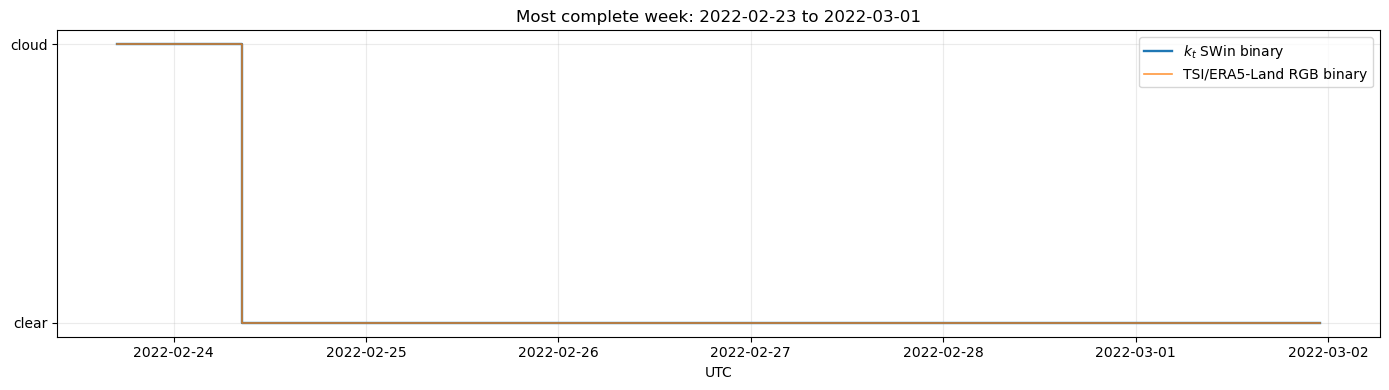

In [6]:
daily_counts = compare.set_index('time').resample('D').size()
week_end = daily_counts.rolling(7, min_periods=1).sum().idxmax()
week_start = week_end - pd.Timedelta(days=6)
week = compare.loc[compare.time.between(week_start, week_end + pd.Timedelta(days=1))]
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(week.time, week.sw_cloud_binary, where='mid', label='$k_t$ SWin binary', lw=1.7)
ax.step(week.time, week.rgb_cloud_binary, where='mid',
        label='TSI/ERA5-Land RGB binary', lw=1.2, alpha=.8)
ax.set_yticks([0, 1], ['clear', 'cloud']); ax.set_xlabel('UTC')
ax.grid(alpha=.25); ax.legend()
ax.set_title(f'Most complete week: {week_start:%Y-%m-%d} to {week_end:%Y-%m-%d}')
fig.tight_layout()
fig.savefig(OUT / 'senator_beck_binary_most_complete_week.png', dpi=200)
plt.show()

## 7. Export comparison products

In [7]:
compare.to_csv(OUT / 'senator_beck_binary_comparison_all_available.csv', index=False)
metrics.to_csv(OUT / 'senator_beck_binary_metrics_all_available.csv', index=False)
hourly_metrics.to_csv(OUT / 'senator_beck_binary_metrics_by_utc_hour.csv', index=False)
monthly_metrics.to_csv(OUT / 'senator_beck_binary_metrics_by_month.csv', index=False)
print('Saved outputs to', OUT.resolve())

Saved outputs to /glade/u/home/cdalden/goes_work/analysis/output_13c_senator_beck_domain_cloud_binary
